# 04. Laboratório de Modelos, Experimentos Temporais e Avaliação Cega

Este notebook concentra a esteira de modelagem.
1. Pré-processamento blindado via `TemporalPreprocessor`.
2. Modelos Baselines e Algoritmo do Zero em $D_0$.
3. Configuração do Modelo Principal ($M_0$).
4. Estratégias temporais: $M_{FT}$, $M_{RT}$, $M_{REC}$.
5. Explicabilidade global (SHAP).
6. Tabela 17 (Avaliação cega final em $D_2$).

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import time
import shap
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, confusion_matrix

sys.path.append(os.path.abspath('..'))
from src.data_processing import TemporalPreprocessor
from src.custom_models import LogisticRegressionCustom

warnings.filterwarnings('ignore')

# 1. Carga de Dados
d0 = pd.read_csv('../data/processed/d0.csv')
d1 = pd.read_csv('../data/processed/d1.csv')
d2 = pd.read_csv('../data/processed/d2.csv')

# 2. Pré-processamento Restrito
preprocessor = TemporalPreprocessor()
X0, y0 = preprocessor.fit(d0).transform(d0)
X1, y1 = preprocessor.transform(d1)
X2, y2 = preprocessor.transform(d2)

# Conjunto Acumulado (Para o Retreinamento Completo)
X01 = np.vstack([X0, X1])
y01 = np.concatenate([y0, y1])

print(f"Shape X0: {X0.shape} | X1: {X1.shape} | X2: {X2.shape}")

c:\Users\55449\Documents\GitHub\spotify-charts-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape X0: (163932, 19) | X1: (57497, 19) | X2: (51350, 19)


## 1. Algoritmo do Zero vs. Baseline da Biblioteca (US05 e US06)

In [2]:
print("--- Regressão Logística Customizada (NumPy) ---")
start = time.time()
custom_lr = LogisticRegressionCustom(learning_rate=0.1, num_iterations=500)
custom_lr.fit(X0, y0)
y_pred_custom = custom_lr.predict(X1)
print(f"F1-Score (Validação em D1): {f1_score(y1, y_pred_custom):.4f} | Tempo: {time.time() - start:.2f}s")

print("\n--- Regressão Logística (Scikit-Learn) ---")
start = time.time()
sk_lr = LogisticRegression(max_iter=500, random_state=42)
sk_lr.fit(X0, y0)
y_pred_sk = sk_lr.predict(X1)
print(f"F1-Score (Validação em D1): {f1_score(y1, y_pred_sk):.4f} | Tempo: {time.time() - start:.2f}s")

print("\n--- Baseline Árvores (Random Forest) ---")
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X0, y0)
y_pred_rf = rf.predict(X1)
print(f"F1-Score (Validação em D1): {f1_score(y1, y_pred_rf):.4f}")

--- Regressão Logística Customizada (NumPy) ---
F1-Score (Validação em D1): 0.3131 | Tempo: 8.71s

--- Regressão Logística (Scikit-Learn) ---
F1-Score (Validação em D1): 0.2997 | Tempo: 0.48s

--- Baseline Árvores (Random Forest) ---
F1-Score (Validação em D1): 0.2225


## 2. Experimentos Temporais: M0, MFT, MRT, MREC

Definimos uma função de avaliação com múltiplas sementes aleatórias (seeds) para garantir robustez estatística, conforme edital. O MLPClassifier será nosso modelo base.

In [3]:
SEEDS = [42, 123, 999]

def train_eval_mlp(X_train, y_train, X_test, y_test, model_params, warm_start_model=None):
    results = []
    trained_models = []
    
    for seed in SEEDS:
        params = model_params.copy()
        params['random_state'] = seed
        
        if warm_start_model is not None:
            # Clona o modelo base preservando os pesos para fine-tuning
            import copy
            mlp = copy.deepcopy(warm_start_model)
            mlp.set_params(random_state=seed, max_iter=20) # Poucas épocas extras
        else:
            mlp = MLPClassifier(**params)
            
        mlp.fit(X_train, y_train)
        y_pred = mlp.predict(X_test)
        y_prob = mlp.predict_proba(X_test)[:, 1]
        
        res = {
            'Acc': accuracy_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred),
            'PR-AUC': average_precision_score(y_test, y_prob)
        }
        results.append(res)
        trained_models.append(mlp)
        
    df_res = pd.DataFrame(results)
    means = df_res.mean()
    stds = df_res.std()
    
    return f"{means['F1']:.4f} ± {stds['F1']:.4f}", f"{means['Acc']:.4f} ± {stds['Acc']:.4f}", f"{means['PR-AUC']:.4f} ± {stds['PR-AUC']:.4f}", trained_models[0]

# Arquitetura Base
base_params = {
    'hidden_layer_sizes': (64, 32),
    'learning_rate_init': 0.001,
    'max_iter': 50,
    'warm_start': True # Fundamental para MFT
}

print("Executando treinamentos em lote (aguarde)...")
# M0: Treino histórico
f1_m0, acc_m0, pr_m0, model_m0 = train_eval_mlp(X0, y0, X2, y2, base_params)

# MFT: Fine-Tuning de M0 usando D1
f1_mft, acc_mft, pr_mft, _ = train_eval_mlp(X1, y1, X2, y2, base_params, warm_start_model=model_m0)

# MRT: Retreinamento do zero com D0+D1
f1_mrt, acc_mrt, pr_mrt, _ = train_eval_mlp(X01, y01, X2, y2, base_params)

# MREC: Treino do zero usando apenas D1
f1_mrec, acc_mrec, pr_mrec, _ = train_eval_mlp(X1, y1, X2, y2, base_params)
print("Treinamentos concluídos!")

Executando treinamentos em lote (aguarde)...
Treinamentos concluídos!


## 3. Interpretabilidade SHAP (US11)

Análise de importância global das variáveis no modelo Histórico $M_0$.

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:08<00:00,  5.85it/s]


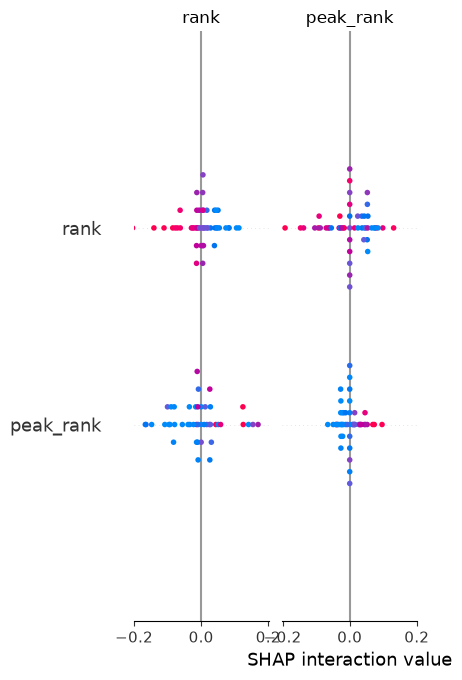

In [5]:
import shap

# 1. Gerar amostra menor para o KernelExplainer (ele é pesado computacionalmente)
X_sample = shap.sample(X1, 50)

# 2. Instanciar o explainer usando a função de probabilidade do MLP
explainer = shap.KernelExplainer(model_m0.predict_proba, X_sample)
shap_values = explainer.shap_values(X_sample)

# 3. Tratamento de compatibilidade da matriz SHAP para classificação binária
# O KernelExplainer para binária costuma retornar uma lista [classe_0, classe_1]
if isinstance(shap_values, list):
    # Pega os valores da classe positiva (índice 1)
    vals = shap_values[1]
else:
    vals = shap_values

# Se houver divergência de dimensionalidade (ex: coluna de bias extra), ajusta:
if vals.shape[1] != X_sample.shape[1]:
    vals = vals[:, :X_sample.shape[1]]

# 4. Geração do Gráfico de Importância Global (Bar Plot)
features_names = preprocessor.feature_names
shap.summary_plot(vals, X_sample, feature_names=features_names, plot_type="bar")

## 4. Tabela 17 - Avaliação Cega Consolidada em D2

Resultado comparativo formal das quatro estratégias de manutenção sob mudança temporal.

In [6]:
tabela_17 = pd.DataFrame([
    {"Modelo": "M0", "Dados Usados": "D0", "Estratégia": "Histórico Fixo", "F1-Score": f1_m0, "Accuracy": acc_m0, "PR-AUC": pr_m0},
    {"Modelo": "MFT", "Dados Usados": "D0 -> D1", "Estratégia": "Fine-Tuning", "F1-Score": f1_mft, "Accuracy": acc_mft, "PR-AUC": pr_mft},
    {"Modelo": "MRT", "Dados Usados": "D0 + D1", "Estratégia": "Retreinamento Completo", "F1-Score": f1_mrt, "Accuracy": acc_mrt, "PR-AUC": pr_mrt},
    {"Modelo": "MREC", "Dados Usados": "D1", "Estratégia": "Apenas Recente", "F1-Score": f1_mrec, "Accuracy": acc_mrec, "PR-AUC": pr_mrec}
])

print("=" * 90)
print("             TABELA 17: DESEMPENHO DOS MODELOS NO CONJUNTO FUTURO (D2)             ")
print("=" * 90)
display(tabela_17)

             TABELA 17: DESEMPENHO DOS MODELOS NO CONJUNTO FUTURO (D2)             


,Modelo,Dados Usados,Estratégia,F1-Score,Accuracy,PR-AUC
0,M0,D0,Histórico Fixo,0.2657 ± 0.0321,0.6340 ± 0.0015,0.5174 ± 0.0029
1,MFT,D0 -> D1,Fine-Tuning,0.2880 ± 0.0080,0.6348 ± 0.0009,0.5229 ± 0.0020
2,MRT,D0 + D1,Retreinamento Completo,0.2609 ± 0.0167,0.6345 ± 0.0010,0.5204 ± 0.0012
3,MREC,D1,Apenas Recente,0.3116 ± 0.0062,0.6331 ± 0.0008,0.5148 ± 0.0011
